# Hierarchical Clustering
Hierarchical clustering is a clustering method that organizes data into a tree-like structure of groups.
- It works either bottom-up (agglomerative) by merging small clusters into bigger ones, or top-down (divisive) by splitting one large cluster into smaller ones.
- The process is visualized using a dendrogram, which shows how clusters are combined or divided step by step.
  
### Methods:
- **Single Linkage (Min):** This algorithm measures the similarity between the nearest points of two clusters.
- **Complete Linkage (Max):** This method focuses on the farthest points when assessing cluster similarity.
- **Group Average:** This approach calculates the average distance between all points in two clusters

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering 
# from scipy.cluster.hierarchy as sch
from scipy.cluster import hierarchy as sch
from sklearn.datasets import make_blobs

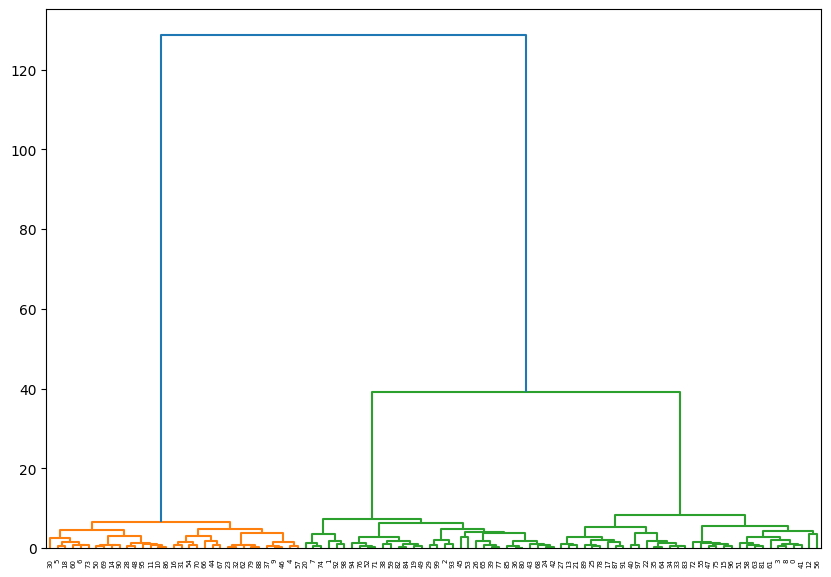

In [7]:
X,y = make_blobs(n_samples=100, centers=3, n_features=3, random_state=42)

clustring = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clustring.fit(X)

plt.figure(figsize=(10,7))
dendrogram = sch.dendrogram(sch.linkage(X,method='ward'))
plt.show()

In [9]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


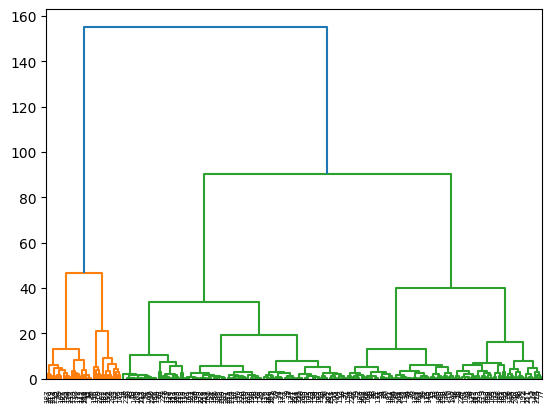

In [24]:
features = ['total_bill','tip','size']
x = df[features]
model = AgglomerativeClustering(n_clusters=3,metric='euclidean', linkage='ward')
model.fit(x)

dendrogram = sch.dendrogram(sch.linkage(x,method='ward'))
plt.show()

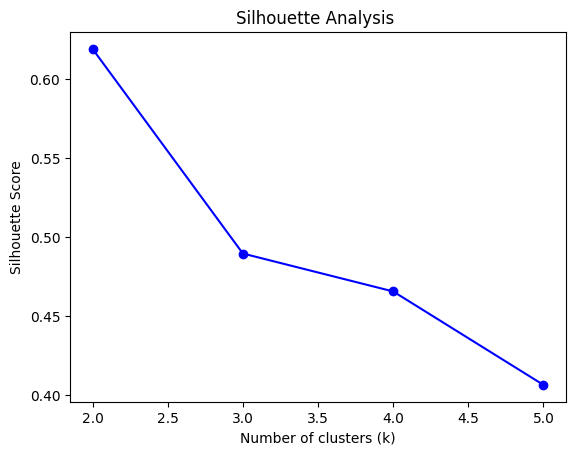

In [26]:
from sklearn.metrics import silhouette_score

n_values = range(2,6)
silhouette = []

for n in n_values:
    model = AgglomerativeClustering(n_clusters=n,metric='euclidean', linkage='ward')
    model.fit_predict(x)
    labels = model.labels_
    score = silhouette_score(x,labels)
    silhouette.append(score)
plt.plot(n_values, silhouette, 'bo-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis ")
plt.show()